# Week 04 PDF 資料輸入與前處理流程 

本週實驗將建構自然語言處理前處理架構 (NLP Pre-processing Architecture)。在各項自然語言處理之核心任務中，資料品質決定模型成效 (Garbage In, Garbage Out, GIGO)。為確保輸入語料之結構完整性，本實驗將建構具備邊界防禦與容錯機制之資料輸入流程 (Data Ingestion Process)。

現代解析與拓撲感知工具 (如 Docling) 可萃取文檔之階層拓撲，產出高品質之結構區塊 (拓撲微型文件)，為後續之文本表徵與下游任務奠定基礎。
<!-- 我們將結合大語言模型 (LLM) 之輔助，克服複雜排版與多語系文檔中之切割邊界挑戰，確保前處理演算法之穩定性。 -->

<!--
# Week 04: Batch Data Ingestion Process

This week's lab constructs an NLP pre-processing architecture. In core NLP tasks, data quality determines model performance (Garbage In, Garbage Out, GIGO). To ensure the structural integrity of the input corpus, this lab will build a data ingestion process equipped with boundary defense and fault-tolerance mechanisms. 

Modern parsing and topology-aware tools (like Docling) can extract document hierarchical topology, producing high-quality structural chunks (topological micro-documents), which lays the foundation for subsequent text representation and downstream tasks. We will integrate LLM assistance to overcome segmentation boundary challenges in complex layouts and multilingual documents, ensuring the stability of pre-processing algorithms.
-->


### 1. 環境建置與依賴套件管理 (Environment & Dependencies)
安裝具備版面感知能力的前沿 SOTA 解析套件 `docling`。

1. 請在 VSCode 的終端機 (Terminal) 中確認已啟動 `.venv` 虛擬環境，並手動安裝本次課程的核心解析套件：
    ```bash
    pip install docling matplotlib
    ```

2. 在專業專案中，我們需要建立 `requirements.txt` 來記錄依賴套件。為了避免指令倒出過多不必要的底層套件，我們在此手動寫入最核心的清單。
    ```bash
    docling
    matplotlib
    ```
>*(進階補充：在業界實務中，工程師常使用 `pipreqs` 套件來自動掃描程式碼並生成最精簡的依賴清單。)*


### 2. 動態掃描資料集 (Dynamic Data Scanning)

本次實驗使用真實的校園規章資料集。我們將透過 `pathlib` 動態掃描 `data/raw/` 底下的子資料夾（如 `Student_Affairs`, `Academic_Affairs`, `Library_Information` 等），這將作為我們後續的 Ground Truth 分類標籤。

`# ps. Jupyter Notebook 的預設工作目錄（Working Directory）是該 .ipynb 檔案所在的資料夾`

In [ ]:
from pathlib import Path
import os

# 檢查目前工作目錄
current_dir = os.getcwd()
print(f"目前工作目錄: {current_dir}")

# 取得目前 Notebook 的絕對路徑
notebook_dir = os.path.abspath('')

# 往上推兩層取得根目錄的絕對路徑
#project_root = os.path.dirname(os.path.dirname(notebook_dir))

# 往上推一層取得根目錄的絕對路徑
project_root = os.path.dirname(notebook_dir)

# 組合出 data/raw 的絕對路徑
RAW_DATA_DIR = Path(os.path.join(project_root, "data", "raw"))

# 組合出 data/interim 的絕對路徑
INTERIM_DATA_DIR = Path(os.path.join(project_root, "data", "interim"))

# 組合出 data/processed 的絕對路徑
PROCESSED_DATA_DIR = Path(os.path.join(project_root, "data", "processed"))

# 確保輸出目錄存在 (Ensure output directories exist)
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# 讀取原始語料庫 (Read raw corpus)
# 掃描次級目錄 (Scan subdirectories: Academic_Affairs, Student_Affairs, Library_Information)
pdf_files = list(RAW_DATA_DIR.glob("*/*.pdf"))

print(f"[Info] 成功掃描到 {len(pdf_files)} 份原始 PDF 規章文檔：\n")
for p in pdf_files:
    # p.parent.name 會自動抓取資料夾名稱作為 Cluster
    print(f"[{p.parent.name}] {p.name}")

if len(pdf_files) == 0:
    print("[Warning] 未找到任何 PDF 檔案，請確認 data/raw/ 下的子資料夾中已有規章檔案。")



目前工作目錄: c:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\local\week_04
[Info] 成功掃描到 9 份原始 PDF 規章文檔：

[Academic_Affairs] A231060004_學生申請期中停修課程實施要點.pdf
[Academic_Affairs] A232020018_大學部學則.pdf
[Academic_Affairs] A232060013_學 生抵免學 分辦法.pdf
[Library_Information] A271010023_圖書館管理作業規範.pdf
[Library_Information] A273020009_學生宿舍學術網路使用及管理辦法.pdf
[Library_Information] A273060005_學生電子郵件帳號管理要點.pdf
[Student_Affairs] A242030012_學生獎懲規定.pdf
[Student_Affairs] A242060013_學生請假作業辦法.pdf
[Student_Affairs] A242100008_學生機車管理辦法.pdf


### 3. 檢視工具拓撲還原的品質 (Parsing ＆ Topology Construction Inspection)


在進行全自動批次處理前，我們先抽出「第一份文件」來檢視拓撲還原的品質。

In [4]:
import os

# Disable Hugging Face symlink creation to prevent WinError 1314 on Windows environments
# 關閉 Hugging Face 的符號連結功能，避免 Windows 環境下觸發 WinError 1314 權限錯誤
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS"] = "1"

# 接下來再匯入 Docling (Ensure Docling is imported AFTER setting the variables)
from docling.document_converter import DocumentConverter

In [11]:
import re
if pdf_files:
    sample_pdf = pdf_files[1] # [Academic_Affairs] A232020018_大學部學則.pdf
    print(f"測試樣本: {sample_pdf.name} (所屬分類: {sample_pdf.parent.name})\n")
    
    # --- Docling 拓撲還原 ---
    converter = DocumentConverter()
    result = converter.convert(sample_pdf) # Parsing
    docling_ir_markdown = result.document.export_to_markdown() # convert to Intermediate Representation (IR)
    
    # 儲存 Docling Markdown 供肉眼審查 (Save Topological IR for human review)
    sota_md_path = INTERIM_DATA_DIR / f"sample_{sample_pdf.stem}_docling_baseline.md"
    with open(sota_md_path, "w", encoding="utf-8") as f:
        f.write(docling_ir_markdown)
    


測試樣本: A232020018_大學部學則.pdf (所屬分類: Academic_Affairs)



[INFO] 2026-09-28 14:50:38,527 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-28 14:50:38,529 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-09-28 14:50:38,537 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-28 14:50:38,538 [RapidOCR] main.py:50: Using C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-28 14:50:38,637 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-28 14:50:38,640 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-09-28 14:50:38,643 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-09-28 14:50:38,644 [RapidOCR] main.py:50: Usin

In [12]:
if docling_ir_markdown:
        # --- 檢視 ---
    print("\n\n=== (Docling) ===")
    print(docling_ir_markdown[:1500] + "...\n")



=== (Docling) ===
## 明志科技大學

## Ming Chi University of Technology

大學部學則

## Academic Regulations for Undergraduate Studies

制定部門：教務處

Formulated by: Office of Academic Affairs, Ming Chi University of Technology

中華民國 113年05月27日 修訂

Amended on May 27, 2024

規章編號

Regulation No.

A232020018

修訂記錄：

Amendment record:

88.09.22校務會議訂定

Formulated by the University Council Meeting on September 22, 1999

80.12.19校務會議修訂

Amended by the University Council Meeting on December 19, 1991

91.03.14校務會議修訂

Amended by the University Council Meeting on March 14, 2002

92.04.14校務會議修訂

Amended by the University Council Meeting on April 14, 2003

92.10.24校務會議修訂

Amended by the University Council Meeting on October 24, 2003

93.11.10校務會議修訂

Amended by the University Council Meeting on November 10, 2004

97.04.29校務會議修訂

Amended by the University Council Meeting on April 29, 2008

98.06.24校務會議修訂

Amended by the University Council Meeting on June 24, 2009

98.11.10校務會議修訂

Amended by the University Council 


### 4. 拓撲邊界驗證與演算法強化 (Topological Boundary Validation & Algorithm Enhancement)

在自然語言處理流程中，處理邊界條件 (Boundary Conditions) 為確保資料品質之關鍵。基礎字串切分往往會破壞文檔之原始拓撲結構。

**邊界驗證與強化邏輯 (Boundary Validation & Enhancement Logics)：**
> 結合失效分析與測試驅動開發 (TDD) 之設計邏輯，邊界條件之驗證與強化流程：
1. **檢視基礎演算法缺陷 (Inspect Baseline Algorithm Flaws)：** 先行執行未處理邊界條件之基礎切割邏輯，觀察其於複雜排版下所產生之資料遺失、拓撲破壞或結構斷裂現象。
2. **確立邊界斷言 (Establish Boundary Assertions)：** 基於上述失效觀察，定義理想之輸入與輸出字串狀態。本實驗之斷言目標為
3. **大語言模型輔助迭代 (LLM-Assisted Iteration)：** 將前述觀察到之失效狀態與斷言目標，轉化為精確之提示詞 (Prompts)，引導大語言模型生成具備進階正則邏輯 之修復程式碼，確保文本區塊之拓撲完整性。


#### 4.1 檢視基礎演算法缺陷 

<!-- #### 4.1 檢視基礎演算法缺陷 -->

1. **雙語標題斷裂:** 中英文標題被強制拆分為連續之獨立標籤 (如連續之 `##`)，導致拓撲結構與雙語語意孤立。

    範例一:

    ```text
    ## 明志科技大學
   
    ## Ming Chi University of Technology
   
    ## Academic Regulations for Undergraduate Studies
   
   制定部門：教務處
   Formulated by: Office of Academic Affairs
    ```

2. **交錯之雙語條文:** 中英對照之內文條例。

    範例一 :
    ```text
    - 第十九條 學生經核准得跨部選修課程。本校「跨部選修課程實施要 點」另訂之。
    - Article 19 Students may take courses offered by other departments with approval. The Directives Governing the Implementation of Inter depart mental Course Selection of the University shall be stipulated separately.
    ```
   範例二 :
    ```text
    - 第十五條 學生每學期修習學分數不得多於廿七學分。
    
    學生前學期學業平均成績在 A-以上 ...

    - Article 15 Students shall not take more than 27 credits in each semester.

    Students who have achieved an average of 80 points or Grade A- or above ...
    ```
3. **頁首頁尾溢出:** 文件之頁首或頁尾字串 (「大學部學則」) 溢出至主文本中，破壞連續語義。

    範例一:
    ```text
    - 第二十一條 本校採學年學分制，四年制各系修業年限為四年。因工讀 實務實習之特色，...

    畢業年級相當於國內高級中等學校二年級之國外或香港、

    ## 大學部學則

    澳門同級同類學校畢業生，以同等學力入學本校大學部一 年級者，...

    - Article 21 Our school adopts an academic year credit system, with a four-year study period for each department. Characterized with the work-study practical internship, ...

    Graduates from schools of the same level in foreign countries, Hong Kong or Macao, or with academic qualifications equivalent to those of the second year of a senior high school in Taiwan, ...
    ```


#### 4.2  確立邊界斷言 (Assertions)

<!-- #### 4.2  確立邊界斷言 (Assertions) -->
> 步驟先後順序: 「先全域除噪，後局部重組 」的系統設計原則。

1. **頁首頁尾溢出清除斷言**
    * **斷言目標:** 排版所產生之孤立溢出字串 (如 ## 大學部學則) 及其伴隨之換行符號必須被完全抹除，使原先被截斷之主文本段落得以重新接壤。
    * **預期輸出 (Expected Output):**

    範例一 :
     
    ```text
    - 第二十一條 本校採學年學分制，四年制各系修業年限為四年。因工讀 實務實習之特色，...

    畢業年級相當於國內高級中等學校二年級之國外或香港、澳門同級同類學校畢業生，以同等學力入學本校大學部一 年級者，...

    - Article 21 Our school adopts an academic year credit system, with a four-year study period for each department. Characterized with the work-study practical internship, ...

    Graduates from schools of the same level in foreign countries, Hong Kong or Macao, or with academic qualifications equivalent to those of the second year of a senior high school in Taiwan, ...
    
    ```

2. **雙語標題合併斷言**
    * **斷言目標:** 具備中英對照性質之連續 Markdown 標題標籤，必須合併為單一階層。為維持乾淨的 Markdown 語法，僅保留首個 ## 標記，後續英文標題應去除 ## 符號，並以 " / " 無縫橋接。合併過程不得吞噬或破壞緊接於標題下方之內文。
    * **預期輸出 (Expected Output):**

    範例一 :
     
    ```text
    ## 明志科技大學 / Ming Chi University of Technology / Academic Regulations for Undergraduate Studies

    制定部門：教務處
    Formulated by: Office of Academic Affairs
    ```

3. **交錯雙語條文合併斷言**
    * **斷言目標:** 具備中英對照性質之連續清單項目 (以 -  開頭)，必須解除換行與多段落斷裂，合併為單一文字區塊，中間以 " / " 橋接。必須能克服多段落與特殊符號干擾。
    * **預期輸出 (Expected Output):**

    範例一 :

    ```text
    - 第十九條 學生經核准得跨部選修課程。本校「跨部選修課程實施要 點」另訂之。 / Article 19 Students may take courses offered by other departments with approval. The Directives Governing the Implementation of Inter depart mental Course Selection of the University shall be stipulated separately.
    ```
    
    範例二 :

    ```text
    - 第十五條 學生每學期修習學分數不得多於廿七學分。
    
    學生前學期學業平均成績在 A-以上 ... / Article 15 Students shall not take more than 27 credits in each semester.

    Students who have achieved an average of 80 points or Grade A- or above ...

    ```




#### 4.3 大語言模型輔助的演算法優化 (Week 04 任務)


#### 4.31 任務 1-A：頁首頁尾溢出清除. 

**[工程限制與提示詞挑戰]：** 
在後續的批次處理迴圈中，系統將面對數十份名稱完全不同的 PDF。因此，**禁止於清除邏輯中將特定法規名稱寫死**。
請檢視程式碼中預先提供給您的變數 `current_filename`。請自行設計提示詞 (Prompt)，要求大語言模型運用此變數作為外部依賴，生成一段具備「動態適應能力 (Dynamic Adaptability)」之正則 (Regular Expression) 清除腳本。

In [ ]:
import re

print("[Start] 執行任務 1-A：頁首頁尾溢出清除")

# 模擬批次處理流程中取得之當前檔案名稱與包含溢出雜訊之原始文本
current_filename = "A232020018_大學部學則.pdf"

raw_topology_1a = """
- 第二十一條 本校採學年學分制，四年制各系修業年限為四年。因工讀 實務實習之特色，...

畢業年級相當於國內高級中等學校二年級之國外或香港、

## 大學部學則

澳門同級同類學校畢業生，以同等學力入學本校大學部一 年級者，...

- Article 21 Our school adopts an academic year credit system, with a four-year study period for each department. Characterized with the work-study practical internship, ...
"""
# =========================================================
# [TDD 斷言目標] (TDD Assertion Target)
# =========================================================

expected_topology_1a = """
- 第二十一條 本校採學年學分制，四年制各系修業年限為四年。因工讀 實務實習之特色，...

畢業年級相當於國內高級中等學校二年級之國外或香港、

澳門同級同類學校畢業生，以同等學力入學本校大學部一 年級者，...

- Article 21 Our school adopts an academic year credit system, with a four-year study period for each department. Characterized with the work-study practical internship, ...
"""

# =========================================================
# TODO: 大語言模型輔助迭代實作區 (LLM-Assisted Iteration Workspace)
# =========================================================

# [TODO 1-A] 詮釋資料萃取 (請將 AI 生成之檔名萃取程式碼貼於此處)
# ai_extract_title_regex = r""


# [測試用中介變數，請於完成 TODO 1-A 後刪除以下此行]
ai_extract_title_regex = r""


# --- (以下為系統預寫之自動萃取與除噪管線，無須修改) ---
if ai_extract_title_regex:
    title_match = re.search(ai_extract_title_regex, current_filename)
    doc_title = title_match.group(1) if title_match else ""
else:
    doc_title = ""

if doc_title:
    dynamic_bleed_regex = rf"(##\s*{doc_title}\n*|{doc_title}\n*)"
    step_1_text = re.sub(dynamic_bleed_regex, "", raw_topology_1a)
else:
    step_1_text = raw_topology_1a

# =========================================================
# [斷言驗證] (Assertion Validation)
# =========================================================
try:
    # 驗證 1：確認法規名稱是否成功動態萃取
    assert ai_extract_title_regex != "", "[Error] 尚未實作正則表示式 ai_extract_title_regex."
    assert 'doc_title' in locals() and doc_title == "大學部學則", f"[Error] 詮釋資料萃取失敗 (Metadata Extraction Failed): 請確認變數 doc_title 是否正確，目前取得 '{doc_title}'。"
    
    # 驗證 2：確認溢出雜訊是否徹底清除且段落成功接壤
    assert step_1_text.strip() == expected_topology_1a.strip(), f"[Error] 溢出清除驗證失敗 (Bleed Clearance Validation Failed):\n{step_1_text}"
    
    print(f"[Info] 成功萃取環境變數 (Environment Variable Extracted): {doc_title}")
    print("[Success] 斷言 1-A 驗證通過：頁首頁尾溢出已動態清除 (Assertion 1-A passed).")
except AssertionError as e:
    print(e)
except Exception as e:
    print(f"[Error] 程式執行異常 (Execution Exception): 尚未實作 TODO 區塊或語法錯誤。\n{e}")

print(step_1_text)

[Start] 執行任務 1-A：頁首頁尾溢出清除
[Info] 成功萃取環境變數 (Environment Variable Extracted): 大學部學則
[Success] 斷言 1-A 驗證通過：頁首頁尾溢出已動態清除 (Assertion 1-A passed).

- 第二十一條 本校採學年學分制，四年制各系修業年限為四年。因工讀 實務實習之特色，...

畢業年級相當於國內高級中等學校二年級之國外或香港、

澳門同級同類學校畢業生，以同等學力入學本校大學部一 年級者，...

- Article 21 Our school adopts an academic year credit system, with a four-year study period for each department. Characterized with the work-study practical internship, ...



#### 4.32 任務 1-B：雙語標題斷裂合併 

**[工程限制與提示詞挑戰]：**
請自行設計提示詞，要求大語言模型運用「捕捉群組 (Capturing Groups)」，精準鎖定「連續兩行皆以 `##` 開頭」的字串特徵，並將換行符號替換為 " / "。請確保正則表示式不會過度貪婪而吃到非標題段落。

<!--
#### 4.4 Task 1-B: Bilingual Heading Fragmentation Consolidation

**1. Inspect Baseline Flaws:**
When processing bilingual physical layouts, parsers frequently force Chinese and English titles into consecutive independent tags (e.g., two consecutive lines starting with `##`). If left unrepaired, subsequent chunking algorithms will generate numerous "Structural Orphans" lacking substantive content.

**2. Establish Assertions:**
Inspect `raw_topology_1b` below. The ideal state, `expected_topology_1b`, must consolidate consecutive independent Markdown heading tags into a single hierarchy, semantically aligned with a " / " symbol in between.

**3. LLM-Assisted Iteration:**
**[Engineering Constraint & Prompt Challenge]:**
Design a prompt requesting the LLM to utilize "Capturing Groups" to precisely target the string feature of "two consecutive lines both starting with `##`", replacing the newline character with " / ". Ensure the regular expression is not overly greedy, preventing it from consuming non-heading paragraphs.
-->

In [ ]:
import re

print("[Start] 執行任務 1-B：雙語標題斷裂合併")

# 模擬已清除頁首頁尾溢出後之文本狀態
raw_topology_1bs = ["""
## 明志科技大學
   
## Ming Chi University of Technology
   
## Academic Regulations for Undergraduate Studies
   
制定部門：教務處
Formulated by: Office of Academic Affairs
""", """
## 第九條 實施與修訂

本辦法經行政會議通過，陳請校長核定後公佈實施，修訂時亦 同。

## Article 9 Implementation and Amendment

The Guidelines shall be passed by the Executive Council and will be enacted and become effective after the approval of the principal. The same shall apply to any amendments to the Procedures.
"""]

# =========================================================
# [TDD 斷言目標] (TDD Assertion Target)
# =========================================================
expected_topology_1bs = ["""
## 明志科技大學 /  Ming Chi University of Technology /  Academic Regulations for Undergraduate Studies
   
制定部門：教務處
Formulated by: Office of Academic Affairs
""",
"""
## 第九條 實施與修訂

本辦法經行政會議通過，陳請校長核定後公佈實施，修訂時亦 同。 /  Article 9 Implementation and Amendment

The Guidelines shall be passed by the Executive Council and will be enacted and become effective after the approval of the principal. The same shall apply to any amendments to the Procedures.
"""]


# =========================================================
# TODO 1-B: 填入大語言模型生成之雙語標題合併邏輯
# =========================================================
# 提示：請將 AI 生成之程式碼貼於此處。
# 目標：將連續相鄰之 Markdown 標題 (##) 進行合併，中間以 " / " 分隔。
ai_merge_headings_regex = r"..."

# [測試用中介變數，請於完成 TODO 1-B 後刪除以下此行]
ai_merge_headings_regex = ""


ai_merge_headings_replace = r"\1 / \2"

for raw_topology_1b, expected_topology_1b in zip(raw_topology_1bs, expected_topology_1bs):

    step_2_text = raw_topology_1b
    while re.search(ai_merge_headings_regex, step_2_text):
        step_2_text = re.sub(ai_merge_headings_regex, ai_merge_headings_replace, step_2_text)

    # =========================================================
    # [斷言驗證] (Assertion Validation)
    # =========================================================
    print("\n\n斷言驗證:===")
    try:
        assert step_2_text.strip() == expected_topology_1b.strip(), f"[Error] 標題合併驗證失敗 :\n{step_2_text}"
        print(f"[Success] 斷言 1-B 驗證通過：雙語標題已成功合併對齊 (Assertion 1-B passed):\n{step_2_text}")
    except AssertionError as e:
        print(e)
    except Exception as e:
        print(f"[Error] 程式執行異常 (Execution Exception): 尚未實作 TODO 區塊或語法錯誤。")
    

[Start] 執行任務 1-B：雙語標題斷裂合併


斷言驗證:===
[Success] 斷言 1-B 驗證通過：雙語標題已成功合併對齊 (Assertion 1-B passed):

## 明志科技大學 /  Ming Chi University of Technology /  Academic Regulations for Undergraduate Studies

制定部門：教務處
Formulated by: Office of Academic Affairs



斷言驗證:===
[Success] 斷言 1-B 驗證通過：雙語標題已成功合併對齊 (Assertion 1-B passed):

## 第九條 實施與修訂

本辦法經行政會議通過，陳請校長核定後公佈實施，修訂時亦 同。 /  Article 9 Implementation and Amendment

The Guidelines shall be passed by the Executive Council and will be enacted and become effective after the approval of the principal. The same shall apply to any amendments to the Procedures.



#### 4.33 任務 1-C：交錯之雙語條文合併

**[工程限制與提示詞挑戰]：**
**防禦升級警告：** 若僅要求 AI 合併「相鄰的兩個清單項目」，系統將會把「第一條 (中文)」與「第二條 (中文)」也錯誤合併！
請自行設計提示詞，引導 AI 運用特徵限制（例如：要求第二個清單項目必須以 **英文字母** 開頭），來確保只有「中-英」對照的條文才會被橋接合體。

<!--
#### 4.5 Task 1-C: Interleaved Bilingual Clauses Consolidation

**1. Inspect Baseline Flaws:**
In regulatory documents, Chinese clauses and their English translations are often parsed as independent list items (both starting with `- `), causing semantic fracture of the same clause within the vector space.

**2. Establish Assertions:**
Inspect `raw_topology_1c` below. The ideal state, `expected_topology_1c`, must merge consecutive list items possessing bilingual comparative properties into a single block.

**3. LLM-Assisted Iteration:**
**[Engineering Constraint & Prompt Challenge]:**
**Defense Upgrade Warning:** If you simply instruct the AI to merge "two adjacent list items," the system will erroneously merge "Article 1 (Chinese)" with "Article 2 (Chinese)"!
Design a prompt to guide the AI in utilizing feature constraints (e.g., mandating that the second list item must begin with an **English letter**) to ensure only "Chinese-English" comparative clauses are bridged together.
-->

In [ ]:
import re

print("[Start] 執行任務 1-C：交錯之雙語條文合併")

# 模擬已完成標題合併後之文本狀態
raw_topology_1c = """
- 第十五條 學生每學期修習學分數不得多於廿七學分。
    
學生前學期學業平均成績在 A-以上 ...

- Article 15 Students shall not take more than 27 credits in each semester.

Students who have achieved an average of 80 points or Grade A- or above ...
"""

# =========================================================
# [TDD 斷言目標] (TDD Assertion Target)
# =========================================================
expected_topology_1c = """
- 第十五條 學生每學期修習學分數不得多於廿七學分。
    
學生前學期學業平均成績在 A-以上 ... /  Article 15 Students shall not take more than 27 credits in each semester.

Students who have achieved an average of 80 points or Grade A- or above ...
"""

# =========================================================
# TODO 1-C: 填入大語言模型生成之條文合併邏輯
# =========================================================
# 提示：請將 AI 生成之程式碼貼於此處。請特別注意防禦邏輯，避免中文與中文條文誤併。
# 目標：將連續之清單項目 (以連字號 "-" 開頭，且一中一英) 進行合併，中間以 " / " 分隔。
# ai_merge_clauses_regex = r"..."

# [測試用中介變數，請於完成 TODO 後移除此行預設宣告]
ai_merge_clauses_regex = r""



ai_merge_clauses_replace = r"\1 / \2"
final_repaired_topology = re.sub(ai_merge_clauses_regex, ai_merge_clauses_replace, raw_topology_1c)

# =========================================================
# [斷言驗證] (Assertion Validation)
# =========================================================
print("\n\n斷言驗證:===")
try:
    assert final_repaired_topology.strip() == expected_topology_1c.strip(), f"[Error] 條文合併驗證失敗:\n{final_repaired_topology}"
    print(f"[Success] 斷言 1-C 驗證通過：雙語條文已成功合併且未發生誤併.\n{final_repaired_topology}")
except AssertionError as e:
    print(e)
except Exception as e:
    print(f"[Error] 程式執行異常 (Execution Exception): 尚未實作 TODO 區塊或語法錯誤。")



[Start] 執行任務 1-C：交錯之雙語條文合併


斷言驗證:===
[Success] 斷言 1-C 驗證通過：雙語條文已成功合併且未發生誤併.

- 第十五條 學生每學期修習學分數不得多於廿七學分。

學生前學期學業平均成績在 A-以上 ... /  Article 15 Students shall not take more than 27 credits in each semester.

Students who have achieved an average of 80 points or Grade A- or above ...



### 5 [自動化批次資料前處理] 邊界感知切塊與結構化輸出 (Automated Pipeline: Boundary-Aware Chunking & Structured Output)

恭喜各位完成了最具挑戰性的「拓撲修復」階段！ 確認解析品質後，我們串接
1.  「中介檔案生成 (Intermediate MD Export)」：將清洗後的法規文本獨立儲存為 `.md` 檔，方便人工抽檢 (Sanity Check)。
2. 「拓撲感知與切塊 (Topology-Aware Chunking)」與
3. 「詮釋資料豐富化 (Metadata Enrichment)」，

對全部文件進行自動化批次處理。


In [ ]:
import os
import json
import re
from pathlib import Path
from docling.document_converter import DocumentConverter

# =========================================================
# 0. 準備環境與固定正則邏輯 (Prepare Env & Regex)
# =========================================================
# 定義資料夾結構 (遵循資料工程金字塔架構)
# 檢查目前工作目錄
current_dir = os.getcwd()
print(f"目前工作目錄: {current_dir}")

# 取得目前 Notebook 的絕對路徑
notebook_dir = os.path.abspath('')

# # 往上推兩層取得根目錄的絕對路徑
#project_root = os.path.dirname(os.path.dirname(notebook_dir))

# 往上推一層取得根目錄的絕對路徑
project_root = os.path.dirname(notebook_dir)

# 組合出 data/raw 的絕對路徑
RAW_DATA_DIR = Path(os.path.join(project_root, "data", "raw"))

# 組合出 data/interim 的絕對路徑
INTERIM_DATA_DIR = Path(os.path.join(project_root, "data", "interim"))

# 組合出 data/raw 的絕對路徑
PROCESSED_DATA_DIR = Path(os.path.join(project_root, "data", "processed"))

# 確保輸出目錄存在 (Ensure output directories exist)
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# 讀取原始語料庫 (Read raw corpus)
# 掃描次級目錄 (Scan subdirectories: Academic_Affairs, Student_Affairs, Library_Information)
pdf_files = list(RAW_DATA_DIR.glob("*/*.pdf"))


# 載入修復與切塊固定邏輯 (來自任務 1-A, 1-B, 1-C)
ai_extract_title_regex = r"" # 任務 1-A

ai_merge_headings_regex = r"" # 任務 1-B
ai_merge_headings_replace = r"\1 / \2"


ai_merge_clauses_regex = r"" # 任務 1-B
ai_merge_clauses_replace = r"\1 / \2"


chunking_regex = r'\n(?=##\s)'

# 初始化 Docling 解析器
converter = DocumentConverter()

print("Initiating Comparative Batch Topology-Aware Chunking Pipeline... (啟動批次拓撲感知切塊流程...)\n")
raw_chunk_dataset_list = []
clean_chunk_dataset_list = []
# 假設 pdf_files 為 pathlib.Path 陣列，例如: list(Path("raw").rglob("*.pdf"))
for pdf_path in pdf_files:
    cluster_label = pdf_path.parent.name 
    print(f"Processing (處理中): [{cluster_label}] {pdf_path.name}")
    
    # 建立叢集專屬目錄
    cluster_interim_dir = INTERIM_DATA_DIR / cluster_label
    cluster_processed_dir = PROCESSED_DATA_DIR / cluster_label
    cluster_interim_dir.mkdir(parents=True, exist_ok=True)
    cluster_processed_dir.mkdir(parents=True, exist_ok=True)
    
    # =========================================================
    # 步驟 1 & 2: 讀取 PDF 並利用 Docling 匯出 Markdown
    # =========================================================
    result = converter.convert(pdf_path)
    raw_markdown = result.document.export_to_markdown()
    
    # 儲存 (2) 原始 Markdown (便於比對修復前後差異)
    raw_md_filepath = cluster_interim_dir / f"raw_{pdf_path.stem}.md"
    raw_md_filepath.write_text(raw_markdown, encoding='utf-8')
    
    # =========================================================
    # 步驟 3: 清洗 Markdown (Topology Repair)
    # =========================================================
    # 從檔名萃取法規名稱 (假設檔名格式如 A231060004_學生申請期中停修課程實施要點.pdf)
    title_match = re.search(r'_(.*?)\.pdf', pdf_path.name)
    doc_title = title_match.group(1) if title_match else pdf_path.stem
    
    # [Task 1-A] 動態除噪
    dynamic_bleed_regex = rf"(##\s*{doc_title}\n*|{doc_title}\n*)"
    step_1 = re.sub(dynamic_bleed_regex, "", raw_markdown)
    
    # [Task 1-B] 雙語標題合併
    step_2 = re.sub(ai_merge_headings_regex, ai_merge_headings_replace, step_1)
    
    # [Task 1-C] 雙語條文合併
    cleaned_markdown = re.sub(ai_merge_clauses_regex, ai_merge_clauses_replace, step_2)
    
    # 儲存 (3) 清洗後的中介 Markdown (供人工抽檢)
    cleaned_md_filepath = cluster_interim_dir / f"cleaned_{pdf_path.stem}.md"
    cleaned_md_filepath.write_text(cleaned_markdown.strip(), encoding='utf-8')
    
    # =========================================================
    # 步驟 4: 邊界感知切塊與 JSON 結構資料序列化處存
    # =========================================================
    raw_chunks = re.split(chunking_regex, cleaned_markdown.strip())
    clean_chunks = [chunk.strip() for chunk in raw_chunks if chunk.strip()]
    
    clean_chunk_dataset = []
    for chunk_text in clean_chunks:
        # 動態捕捉當前切塊的標題層級 (擷取第一行 ## 開頭的文字)
        heading_match = re.match(r'^(##\s[^\n]+)', chunk_text)
        current_heading = heading_match.group(1).strip() if heading_match else ""
        
        # 依照指定 Schema 構建資料結構
        processed_document = {
            "text": chunk_text,
            "metadata": {
                "source_file": pdf_path.name,
                "cluster": cluster_label,
                "char_length": len(chunk_text),
                "headings": [current_heading] if current_heading else [],
                "chunk_type": "regex_parsed"
            }
        }
        clean_chunk_dataset.append(processed_document)
    
    # 輸出最終 JSON 檔案
    clean_json_filepath = cluster_processed_dir / f"cleaned_{pdf_path.stem}_processed.json"
    with open(clean_json_filepath, 'w', encoding='utf-8') as f:
        json.dump(clean_chunk_dataset, f, ensure_ascii=False, indent=4)

    # =============================================================
    # 未清洗之 markdown JSON 結構資料序列化處存
    raw_chunks = re.split(chunking_regex, raw_markdown.strip())
    chunks = [chunk.strip() for chunk in raw_chunks if chunk.strip()]
    
    raw_chunk_dataset = []
    for chunk_text in chunks:
        # 動態捕捉當前切塊的標題層級 (擷取第一行 ## 開頭的文字)
        heading_match = re.match(r'^(##\s[^\n]+)', chunk_text)
        current_heading = heading_match.group(1).strip() if heading_match else ""
        
        # 依照指定 Schema 構建資料結構
        processed_document = {
            "text": chunk_text,
            "metadata": {
                "source_file": pdf_path.name,
                "cluster": cluster_label,
                "char_length": len(chunk_text),
                "headings": [current_heading] if current_heading else [],
                "chunk_type": "regex_parsed"
            }
        }
        raw_chunk_dataset.append(processed_document)
    
    # 輸出最終 JSON 檔案
    raw_json_filepath = cluster_processed_dir / f"raw_{pdf_path.stem}_processed.json"
    with open(raw_json_filepath, 'w', encoding='utf-8') as f:
        json.dump(raw_chunk_dataset, f, ensure_ascii=False, indent=4)
        
    print(f"  [+] 產出中介檔案 (Interim): raw_{pdf_path.stem}.md, cleaned_{pdf_path.stem}.md")
    print(f"  [+] 產出處理檔案 (Processed): {raw_json_filepath.name} (共 {len(chunks)} )\n\t {clean_json_filepath.name} (共 {len(clean_chunks)} )\n")

    raw_chunk_dataset_list.append(raw_chunk_dataset)
    clean_chunk_dataset_list.append(clean_chunk_dataset)
print("[Success] 批次管線執行完畢！所有實體檔案皆已完成轉換、清洗與結構資料序列化處存。 (Batch pipeline finished!)")

目前工作目錄: c:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\local\week_04
Initiating Comparative Batch Topology-Aware Chunking Pipeline... (啟動批次拓撲感知切塊流程...)

Processing (處理中): [Academic_Affairs] A231060004_學生申請期中停修課程實施要點.pdf


[INFO] 2026-09-28 23:45:09,688 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-28 23:45:09,755 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-09-28 23:45:09,773 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-28 23:45:09,774 [RapidOCR] main.py:50: Using C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-28 23:45:10,181 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-28 23:45:10,181 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-09-28 23:45:10,189 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\User\C_Teaching115\115s1_nlp\nlp_course_demo\.venv\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-09-28 23:45:10,190 [RapidOCR] main.py:50: Usin

2026-09-28 23:45:30,797 MatchingPostProcessor WARNING  21 of 45 pdf cells matched neither a row nor a column band of the 2x2 grid and were dropped from the table
  [+] 產出中介檔案 (Interim): raw_A231060004_學生申請期中停修課程實施要點.md, cleaned_A231060004_學生申請期中停修課程實施要點.md
  [+] 產出處理檔案 (Processed): raw_A231060004_學生申請期中停修課程實施要點_processed.json (共 12 )
	 cleaned_A231060004_學生申請期中停修課程實施要點_processed.json (共 11 )

Processing (處理中): [Academic_Affairs] A232020018_大學部學則.pdf
  [+] 產出中介檔案 (Interim): raw_A232020018_大學部學則.md, cleaned_A232020018_大學部學則.md
  [+] 產出處理檔案 (Processed): raw_A232020018_大學部學則_processed.json (共 43 )
	 cleaned_A232020018_大學部學則_processed.json (共 22 )

Processing (處理中): [Academic_Affairs] A232060013_學生抵免學分辦法.pdf
  [+] 產出中介檔案 (Interim): raw_A232060013_學生抵免學分辦法.md, cleaned_A232060013_學生抵免學分辦法.md
  [+] 產出處理檔案 (Processed): raw_A232060013_學生抵免學分辦法_processed.json (共 41 )
	 cleaned_A232060013_學生抵免學分辦法_processed.json (共 24 )

Processing (處理中): [Library_Information] A271010023_圖書館管理作業規範.pdf
2026-09-28 2

#### 5.1: JSON 資料檢視


資料工程要求對序列化輸出進行實證驗證。雖然生成的 JSON 檔案包含數千行文字，但您可以利用 VSCode 的原生功能，無須安裝第三方擴充套件，即可高效檢視其階層結構。

**Inspection Workflow (檢視工作流):**
1. **Locate the File (定位檔案):
   請至 VSCode 左側檔案總管，開啟 `data/processed/Academic_Affairs/cleaned_A231060004_學生申請期中停修課程實施要點_processed.json`。
2. **Document Formatting (文件格式化):** 
   確保 JSON 結構對齊良好。
   * Windows: `Shift + Alt + F`
   * Mac: `Shift + Option + F`
3. **Hierarchical Folding (階層折疊 - 關鍵技巧):**
   為避免無止盡的滾動，請折疊所有子節點，僅檢視根陣列結構。
   * Windows: Press `Ctrl + K` followed by `Ctrl + 0` (Zero).
   * Mac: Press `Cmd + K` followed by `Cmd + 0` (Zero).
   * *Note: You can subsequently unfold specific micro-documents (using the `>` icon in the gutter) to verify their `metadata` and `text` integrity.*
   * *註：隨後您可以展開特定的微型文件（點擊行號旁的 `>` 圖示），以驗證其 `metadata` 與 `text` 的完整性。*
   


### 6. 拓撲感知切塊品質之比較型實證評估　(Comparative Empirical Evaluation of Topology-Aware Chunking Quality)

#### 比較型實證評估，建立一項基準認知：早期的結構性退化(將如何影響整個 NLP 下游任務表現)。

在進入向量空間模型之前，針對四個關鍵維度，初步 (第一階段) 評估產出的資料集。這些指標涵蓋了從基礎形態限制到進階資訊理論，為資料品質建立了嚴謹的基準：

<!-- Before advancing to Vector Space Models, we evaluate the generated datasets across five critical dimensions. 
These metrics range from basic morphological constraints to advanced information theory, establishing a rigorous baseline for data quality: -->


1. **形態可行性 (Morphological Viability):**
   評估區塊長度分佈，確保符合大型語言模型 (LLM) 上下文視窗的閾值，同時減緩「主題稀釋」與「資訊碎片化」問題。

   <!-- Evaluates chunk length distributions to ensure compliance with Large Language Model (LLM) Context Window thresholds, mitigating both *Topic Dilution* and *Information Fragmentation*. -->
   

2. **拓撲錨(ㄇㄠˊ)定率 (Topological Anchoring Ratio, TAR):**
   量化成功由階層標題 (`#`, `##`) 引導的區塊比例。高 TAR 證實了拓撲邊界在邏輯上與作者的原始文件結構一致，而非任意的文本斷裂。

   <!-- Quantifies the proportion of chunks successfully led by a hierarchical header (`#`, `##`). A high TAR validates that the topological boundaries logically align with the author's original document structure, rather than arbitrary textual ruptures. -->
   

3. **結構深度變異數 (Structural Depth Variance):**
   分析微型文件中 Markdown 標題層級的分佈狀態。測量解析模型識別次級條款的能力。(值越高 -- > 能力越強)。

   <!-- Analyzes the hierarchical distribution of Markdown headers (e.g., `#` vs `###`). It measures the parsing model's capability to recognize nested sub-clauses, avoiding overly shallow or artificially deep structures. (Higher value -- > better) -->
   

4. **夏農資訊熵 ㄕㄤ (Shannon Information Entropy):**
   源自資訊理論，在字元層級上計算機率的不可預測性。純數學的資訊飽和度測試。(熵越高 -- > 資訊飽和度越高)。

   <!-- Derived from Information Theory, calculating the unpredictability of character occurrence. Pure mathematical saturation test—low entropy indicates repetitive boilerplate, whereas high entropy indicates rich regulatory details.  -->
   


=== Advanced Comparative Diagnostics (進階比較型診斷結果) ===
[1] 形態可行性 Morphology (Median Length): Cleaned = 392.5 | Raw = 205.0
[2] 拓撲錨定率 Topology (TAR Score):     Cleaned = 100.00% | Raw = 100.00%
[3] 深度變異量 Depth Variance (SDV):     Cleaned = 0.00 | Raw = 0.00
[4] 夏農資訊熵 Information (Median Entropy):Cleaned = 5.24 | Raw = 4.72

評估指標已成功儲存至: ../../metrics.json


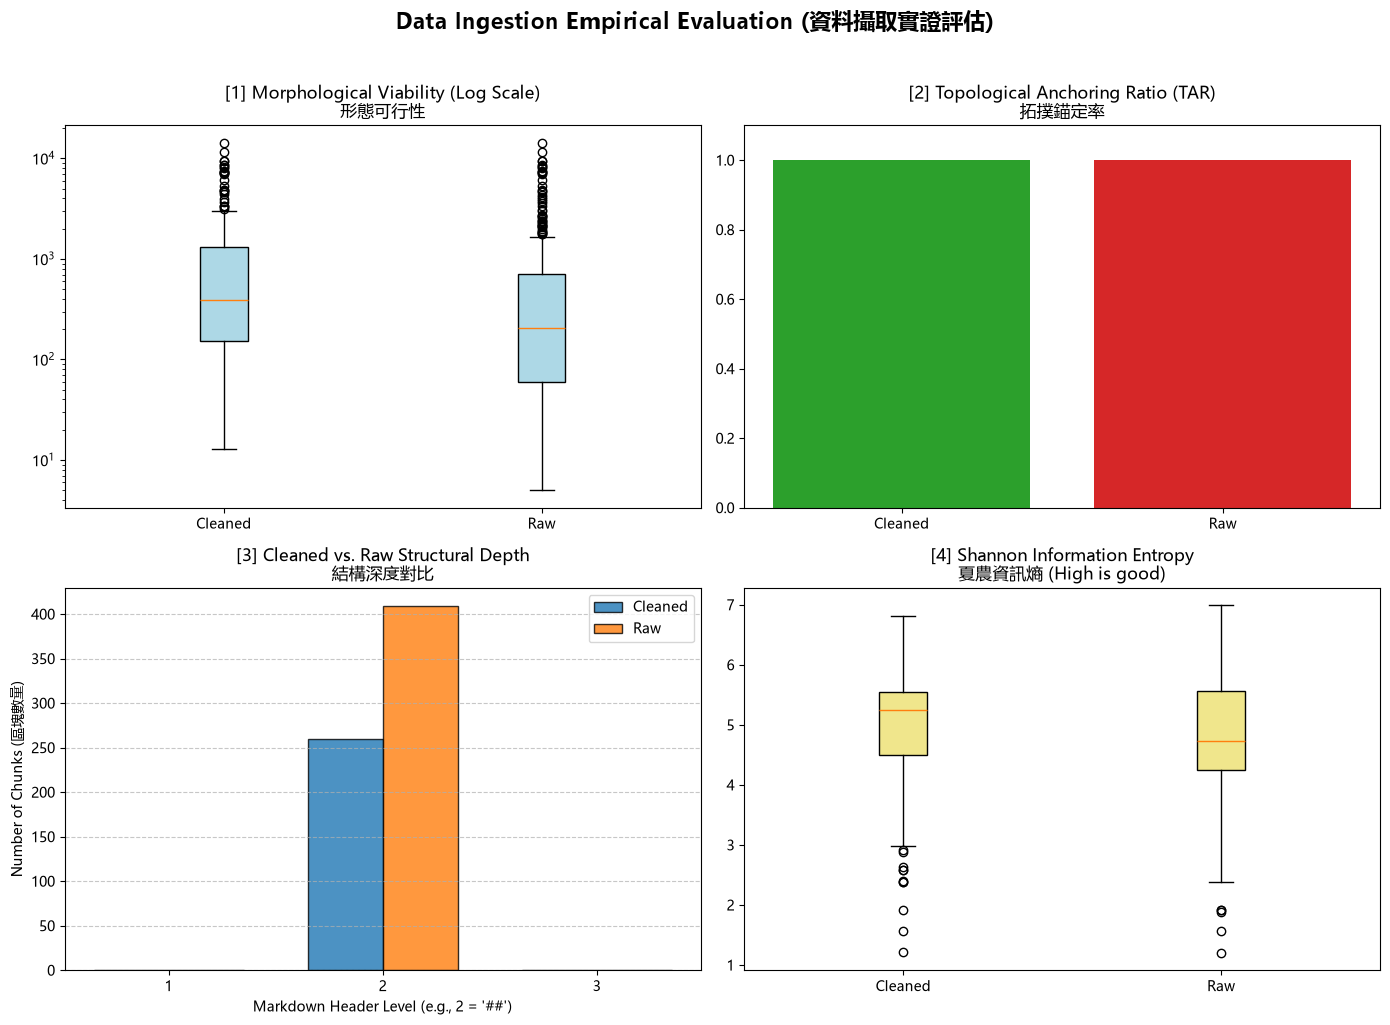

In [6]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Set a list of common fallback Chinese fonts for Windows, macOS, and Linux
plt.rcParams['font.sans-serif'] = ['SimHei', 'Heiti TC', 'PingFang HK', 'Microsoft YaHei', 'Arial Unicode MS']

# 2. Fix the issue where the minus sign '-' displays as a broken box
plt.rcParams['axes.unicode_minus'] = False


# --- 1. Define Metric Extraction Functions (定義指標萃取函式) ---

def get_lengths(dataset):
    return [record["metadata"]["char_length"] for record in dataset if record["text"]]

def get_tar(dataset):
    anchored = [1 for record in dataset if re.match(r'^\s*#+', record["text"])]
    return len(anchored) / len(dataset) if dataset else 0

def get_depths(dataset):
    """
    Extracts the depth (number of '#') from anchored chunks.
    萃取錨定區塊的標題深度 (例如 '##' 回傳 2)。
    """
    depths = []
    for record in dataset:
        match = re.match(r'^\s*(#+)', record["text"])
        if match:
            depths.append(len(match.group(1)))
    return depths if depths else [0] # 回傳 0 代表完全無結構 (Legacy)

def get_entropy(dataset):
    """
    Calculates Shannon Entropy for each chunk.
    計算每個微型文件的夏農資訊熵: H(X) = -sum(p(x) * log2(p(x)))
    """
    entropies = []
    for record in dataset:
        text = record["text"]
        if not text: continue
        length = len(text)
        counts = Counter(text)
        ent = -sum((freq / length) * math.log2(freq / length) for freq in counts.values())
        entropies.append(ent)
    return entropies if entropies else [0]

# --- 2. Extract Metrics for Comparison (萃取比較指標) ---
raw_chunk_dataset = [chunk for pdf_dataset in raw_chunk_dataset_list for chunk in pdf_dataset]
clean_chunk_dataset = [chunk for pdf_dataset in clean_chunk_dataset_list for chunk in pdf_dataset]

clean_len, raw_len = get_lengths(clean_chunk_dataset), get_lengths(raw_chunk_dataset)
clean_tar, raw_tar = get_tar(clean_chunk_dataset), get_tar(raw_chunk_dataset)
clean_depths, raw_depths = get_depths(clean_chunk_dataset), get_depths(raw_chunk_dataset)
clean_ent, raw_ent = get_entropy(clean_chunk_dataset), get_entropy(raw_chunk_dataset)

print("=== Advanced Comparative Diagnostics (進階比較型診斷結果) ===")
print(f"[1] 形態可行性 Morphology (Median Length): Cleaned = {np.median(clean_len):.1f} | Raw = {np.median(raw_len):.1f}")
print(f"[2] 拓撲錨定率 Topology (TAR Score):     Cleaned = {clean_tar:.2%} | Raw = {raw_tar:.2%}")
print(f"[3] 深度變異量 Depth Variance (SDV):     Cleaned = {np.var(clean_depths):.2f} | Raw = {np.var(raw_depths):.2f}")
print(f"[4] 夏農資訊熵 Information (Median Entropy):Cleaned = {np.median(clean_ent):.2f} | Raw = {np.median(raw_ent):.2f}\n")


metrics_data = {
    "結構健全度 Phase_1_Mechanical_Sanity": {
        " 形態可行性 Morphology_Median_Length": {
            # 使用 np.median 取中位數，並用 float() 轉換以確保 JSON 可序列化
            "Cleaned": float(np.median(clean_len)), 
            "Raw": float(np.median(raw_len))
        },
        "拓撲錨定率 Topology_TAR_Score": {
            "Cleaned": float(clean_tar),  
            "Raw": float(raw_tar)      
        },
        "深度變異量 Depth_Variance_SDV": {
            "Cleaned":  float(np.var(clean_depths)), 
            "Raw":  float(np.var(raw_depths))     
        }
    },
    "語意品質 Phase_2_Semantic_Quality": {
        "夏農資訊熵 Information_Median_Entropy": {
            "Cleaned": float(np.median(clean_ent)),
            "Raw": float(np.median(raw_ent))
        }
    }
}
# ==========================================
# 匯出至 JSON 檔案
# ==========================================
# Notebook 在 notebook/ 目錄下，使用 ../ 將檔案存至專案根目錄
output_path = "../../metrics.json"

with open(output_path, "w", encoding="utf-8") as f:
    # ensure_ascii=False 允許儲存非英文或特殊字元
    # indent=4 會自動縮排，讓產出的 JSON 檔案具備極佳的肉眼可讀性
    json.dump(metrics_data, f, ensure_ascii=False, indent=4)

print(f"評估指標已成功儲存至: {output_path}")


# --- 3. Visualization Matrix 2x2 (視覺化矩陣) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle("Data Ingestion Empirical Evaluation (資料攝取實證評估)", fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Morphological Viability
axes[0, 0].boxplot([clean_len, raw_len], tick_labels=['Cleaned', 'Raw'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0, 0].set_yscale('log') 
axes[0, 0].set_title("[1] Morphological Viability (Log Scale)\n形態可行性")

# Plot 2: Topological Anchoring Ratio (TAR)
axes[0, 1].bar(['Cleaned', 'Raw'], [clean_tar, raw_tar], color=['#2ca02c', '#d62728'])
axes[0, 1].set_ylim(0, 1.1)
axes[0, 1].set_title("[2] Topological Anchoring Ratio (TAR)\n拓撲錨定率")


# Plot 3: Cleaned vs. Raw Structural Depth (合併對比)

# Calculate the frequency of each Markdown header level 計算各階層的分佈數量
clean_counts = Counter(clean_depths)
raw_counts = Counter(raw_depths)

# Determine the X-axis range 決定 X 軸的級距 (涵蓋 Clean 與 Raw 所有的 Header Level)
all_levels = set(clean_counts.keys()).union(set(raw_counts.keys()))
if not all_levels:
    levels = np.array([0])
else:
    # Create a continuous integer array 建立連續的整數陣列 (例如從 1 到最大的 level)
    levels = np.arange(1, max(all_levels) + 2) 

c_vals = [clean_counts.get(lvl, 0) for lvl in levels]
r_vals = [raw_counts.get(lvl, 0) for lvl in levels]

# Plot the Grouped Bar Chart 繪製群組長條圖 (Grouped Bar Chart)
width = 0.35
axes[1, 0].bar(levels - width/2, c_vals, width, label='Cleaned', color='#1f77b4', edgecolor='black', alpha=0.8)
axes[1, 0].bar(levels + width/2, r_vals, width, label='Raw', color='#ff7f0e', edgecolor='black', alpha=0.8)

# Configure labels, title, and styling 標籤與樣式設定
axes[1, 0].set_title("[3] Cleaned vs. Raw Structural Depth\n結構深度對比")
axes[1, 0].set_xlabel("Markdown Header Level (e.g., 2 = '##')")
axes[1, 0].set_xticks(levels)
axes[1, 0].legend()
axes[1, 0].set_ylabel("Number of Chunks (區塊數量)")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)


# Plot 4: Shannon Information Entropy
axes[1, 1].boxplot([clean_ent, raw_ent], tick_labels=['Cleaned', 'Raw'], patch_artist=True, boxprops=dict(facecolor='khaki'))
axes[1, 1].set_title("[4] Shannon Information Entropy\n夏農資訊熵 (High is good)")



plt.tight_layout()
plt.show()

### 7. AI 協作反思 AI_Usage.md 

身為未來的資料工程師與 MLOps 專家，懂得如何與 AI 工具 (如 ChatGPT, Gemini, Claude, GitHub Copilot 等) 高效且負責任地協作，是一項至關重要的技能。

請在專案根目錄建立或開啟 `AI_Usage.md` 檔案，並根據本次「資料擷取與拓撲感知分塊」的實作過程，誠實記錄您的 AI 協作經驗。請務必包含以下五個段落：

#### 1. 使用的 AI 工具 (Tools Used)
* 列出您在此作業中使用的 AI 輔助工具及版本（例如：ChatGPT-4o, Gemini 1.5 Pro, GitHub Copilot）。

#### 2. 主要協作情境 (Use Cases)
* 簡述您在哪些具體任務上尋求了 AI 的協助？
* *(提示範例：請 AI 幫忙寫合併雙語標題的 Regex、請 AI 抓取 matplotlib 群組長條圖的 bug、請 AI 解釋中位數與平均數在長度分佈上的差異等。)*

#### 3. 關鍵提問紀錄 (Key Prompts)
* 貼上 1 到 2 個您認為下得最好、或者經過多次迭代才成功的 Prompt。
* 說明為什麼這個 Prompt 能夠引導 AI 給出您需要的答案。

#### 4. 人類審查與修正 (Human Oversight & Corrections)
* 記錄 AI 在哪個環節「給了錯誤或不適合的建議」，而您是如何發現並修正它的？

#### 5. 總結反思 (Reflection)
* 透過本週的作業，您對於「使用 AI 輔助資料清洗與指標計算」有什麼新的體會？



### 8. README.md 更新

請將以下「Week 4 任務清單」複製貼上，並將您本週已完成的項目打勾（`[x]`）：

```text
### Week 4: Data Ingestion & Topology-Aware Chunking
- [ ] **環境建置與版控防護**：更新 `.gitignore` 成功阻擋原始 PDF 與暫存 JSON，並保留 `.keep` 目錄結構。
- [ ] **資料擷取與合併**：成功實作 Regex，將斷裂的中英雙語標題合併。
- [ ] **結構健全度 (Mechanical Sanity)**：
  - [ ] 拓撲錨定率
  - [ ] 運用「中位數 (Median)」計算文本長度。
- [ ] **語意品質 (Semantic Quality)**：
  - [ ] 成功計算 Shannon Information Entropy (夏農資訊熵)，比較 Cleaned 資料的中位數資訊熵優於 Raw 資料。
- [ ] **觀測儀表板與報告**：
  - [ ] 成功繪製 4 拼圖資料觀測儀表板 (4-Panel Dashboard)。
  - [ ] 成功將核心評估指標匯出為根目錄下的 `metrics.json`。

```


### 9. Git 版本控制 (VSCode 圖形化介面操作)

** 重要：不要將龐大的原始 PDF 與完整的語料 JSON 推送至 GitHub！**
請依照以下步驟透過 VSCode 介面提交作業：

1. **保留執行輸出 (Keep Outputs)**：**請勿**清除 Notebook 的輸出結果！請確保您的 4 拼圖儀表板 (Dashboard) 與進階診斷 Console 輸出都完整保留在 `.ipynb` 畫面中，以便助教檢視您的實證數據。
2. **更新 `.gitignore`**：由於您在 `interim` 與 `processed` 下方皆有多個子資料夾，請使用 `**` (雙星號) 萬用字元來阻擋所有深層的 PDF 與 JSON, md，同時放行所有深層的 `.keep` 檔案：
   ```text
   # Ignore raw PDF and bulk output files in any subdirectories
   data/raw/**/*.pdf
   data/interim/**/*.md
   data/processed/**/*.json
   
   # Always track .keep files to preserve directory structures
   !data/interim/**/.keep
   !data/processed/**/.keep
   ```

3. **開啟版控面板**：點擊 VSCode 左側邊欄的 **「原始檔控制 (Source Control)」** 圖示 (或按 `Ctrl+Shift+G`)。
4. **檢查並暫存變更 (Stage)**：請嚴格執行提交流程檢核，變更清單中只應該出現以下檔案。確認無誤後，將滑鼠移到這些檔案上方，點擊 + (暫存變更)：

   * 01_Data_Ingestion.ipynb (包含完整執行圖表輸出的主程式碼)

   * requirements.txt (填入本週新增套件)

   * AI_Usage.md (您的 AI 協作反思紀錄)

   * README.md (更新至 Week 04)

   * metrics.json (您輸出的核心評估指標檔案)

   * data/interim/ 與 data/processed/ 及其所有子資料夾下建立的 .keep 檔案 (用於保留空目錄結構)

5. **撰寫訊息與提交**：在上方文字方塊輸入以下 Commit 訊息：
feat: 實作批次資料解析與拓撲感知分塊
接著點擊 「提交 (Commit)」，最後點擊 「同步變更 (Sync Changes)」，將您本週的成果推送到 GitHub！
